In [23]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT / "src"))

import importlib
import config
import visualizer
importlib.reload(config)
importlib.reload(visualizer)

import pandas as pd
from config import TABLES_DIR, FIGURES_DIR, COPARISON_DIR
from visualizer import TopicVisualizer

In [9]:
# --------------------------------------------------
# Load both already-computed evaluation results
# (baseline from 01_baseline_bertopic.ipynb,
#  fine-tuned from 02_finetuning.ipynb Part 2)
# --------------------------------------------------

baseline_results = pd.read_csv(TABLES_DIR / "baseModel_topic_evaluation.csv")
finetuned_results = pd.read_csv(TABLES_DIR / "finetuned_topic_evaluation.csv")

print("BaseModel topic evaluation")
print(baseline_results)
print("-"*43)
print("Finetuned topic evaluation")
print(finetuned_results)

BaseModel topic evaluation
                          Metric    Value
0  Coherence (using c_v methode)   0.6835
1                      Diversity   0.9000
2              Outlier Ratio (%)  15.0754
3                            NMI   0.6886
4                         Purity   0.8619
-------------------------------------------
Finetuned topic evaluation
                          Metric   Value
0  Coherence (using c_v methode)  0.7364
1                      Diversity  0.8100
2              Outlier Ratio (%)  3.3501
3                            NMI  0.7040
4                         Purity  0.9003


In [10]:
# --------------------------------------------------
# Merge into one side-by-side comparison table
# --------------------------------------------------

comparison_df = baseline_results.merge(
    finetuned_results, on="Metric", suffixes=("_baseline", "_finetuned")
)

comparison_df.to_csv(COPARISON_DIR / "model_comparison.csv", index=False, encoding='utf-8-sig')
comparison_df

,Metric,Value_baseline,Value_finetuned
0,Coherence (using c_v methode),0.6835,0.7364
1,Diversity,0.9000,0.8100
2,Outlier Ratio (%),15.0754,3.3501
3,NMI,0.6886,0.7040
4,Purity,0.8619,0.9003


In [11]:
# --------------------------------------------------
# Reshape to wide format for TopicVisualizer's comparison
# plots (they expect: one row per model, one column per metric)
# --------------------------------------------------

radar_df = pd.DataFrame({
    "Model": ["Baseline", "Fine-tuned"],
    **{
        row["Metric"]: [
            baseline_results.loc[baseline_results["Metric"] == row["Metric"], "Value"].values[0],
            finetuned_results.loc[finetuned_results["Metric"] == row["Metric"], "Value"].values[0]
        ]
        for _, row in baseline_results.iterrows()
    }
})

radar_df

,Model,Coherence (using c_v methode),Diversity,Outlier Ratio (%),NMI,Purity
0,Baseline,0.6835,0.90,15.0754,0.6886,0.8619
1,Fine-tuned,0.7364,0.81,3.3501,0.7040,0.9003


In [12]:
# --------------------------------------------------
# Topic count comparison needs its own small dataframe
# --------------------------------------------------

baseline_topic_info = pd.read_csv(TABLES_DIR / "topic_information.csv")
finetuned_topic_info = pd.read_csv(TABLES_DIR / "finetuned_tables" / "topic_information.csv")

topic_count_df = pd.DataFrame({
    "Model": ["Baseline", "Fine-tuned"],
    "Topic Count": [len(baseline_topic_info) - 1, len(finetuned_topic_info) - 1]
})

topic_count_df

,Model,Topic Count
0,Baseline,8
1,Fine-tuned,10


In [15]:
# --------------------------------------------------
# Generate comparison figures — each plotting method
# expects a different dataframe shape, so build all
# three shapes explicitly before calling them.
# --------------------------------------------------

topic_visualizer = TopicVisualizer(topic_model=None, statistics=None)

# 1. LONG format for plot_metric_comparison — needs a literal "Metric" column
metric_comparison_df = comparison_df.copy()   # this is the earlier merged long-format table
# columns are: Metric, Value_baseline, Value_finetuned  -- already correct shape

# 2. WIDE format for plot_radar_comparison — first col = model, rest = metrics
# (radar_df from before, already correct shape)

# 3. Outlier-specific df — must be named EXACTLY "Model" / "Outlier Percentage"
outlier_row = comparison_df[comparison_df["Metric"] == "Outlier Ratio (%)"]
outlier_comparison_df = pd.DataFrame({
    "Model": ["Baseline", "Fine-tuned"],
    "Outlier Percentage": [
        outlier_row["Value_baseline"].values[0],
        outlier_row["Value_finetuned"].values[0]
    ]
})

# 4. topic_count_df already built earlier with "Model"/"Topic Count"

comparison_figs = {}
comparison_figs["metric_comparison"] = topic_visualizer.plot_metric_comparison(metric_comparison_df)
comparison_figs["topic_count_comparison"] = topic_visualizer.plot_topic_count_comparison(topic_count_df)
comparison_figs["outlier_comparison"] = topic_visualizer.plot_outlier_comparison(outlier_comparison_df)
comparison_figs["radar_comparison"] = topic_visualizer.plot_radar_comparison(radar_df)

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
topic_visualizer.save_all_figures(COPARISON_DIR / "comparison_figs")


All figures were saved to:
D:\proposal\thiese\code\Persian-Topic-Modeling\results\comparison\comparison_figs


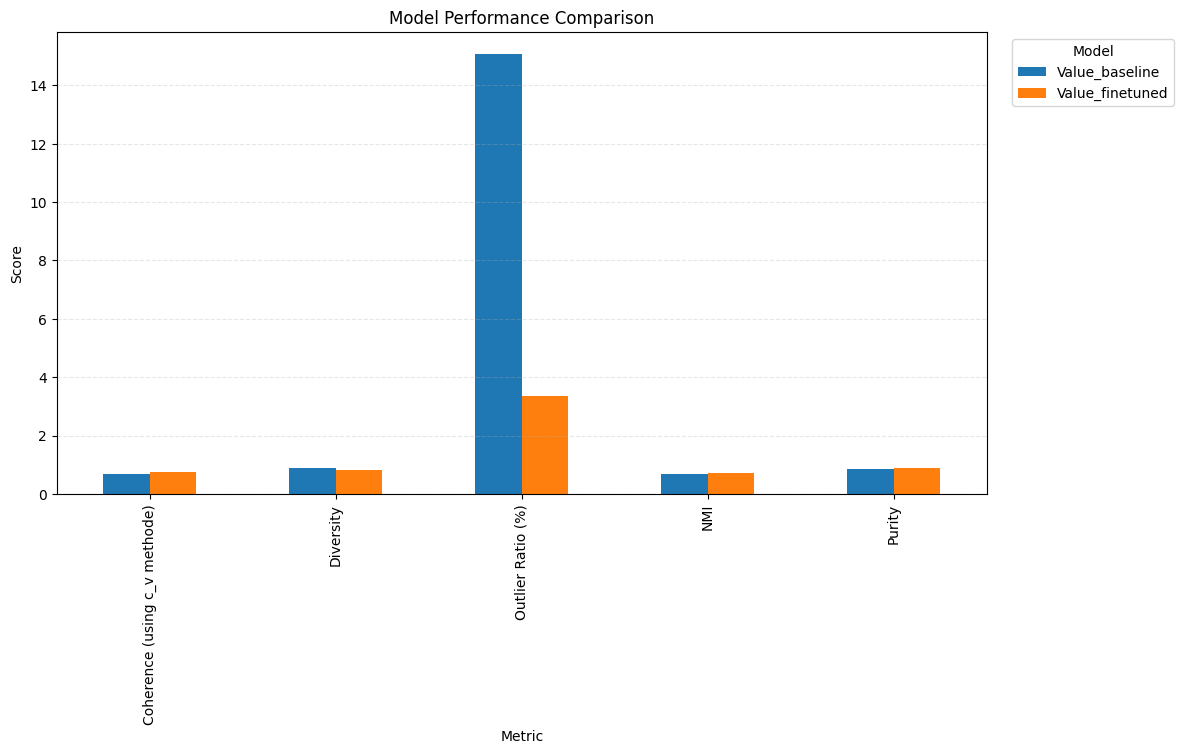

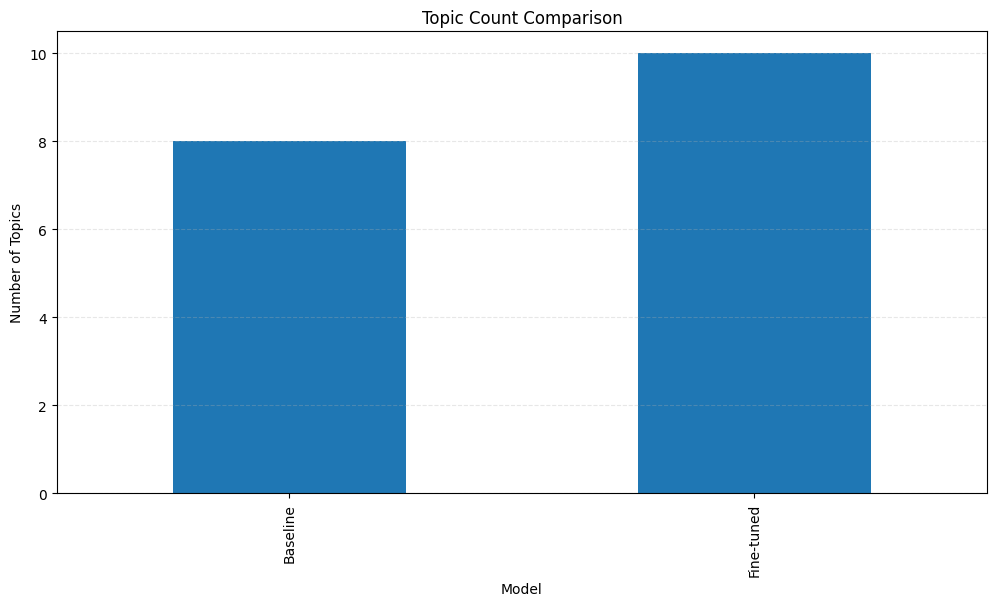

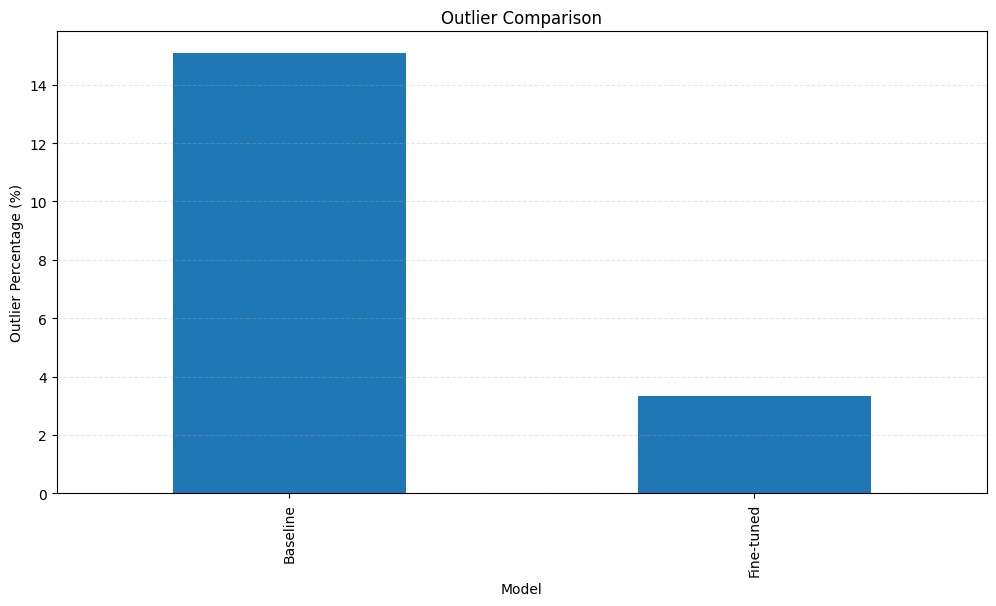

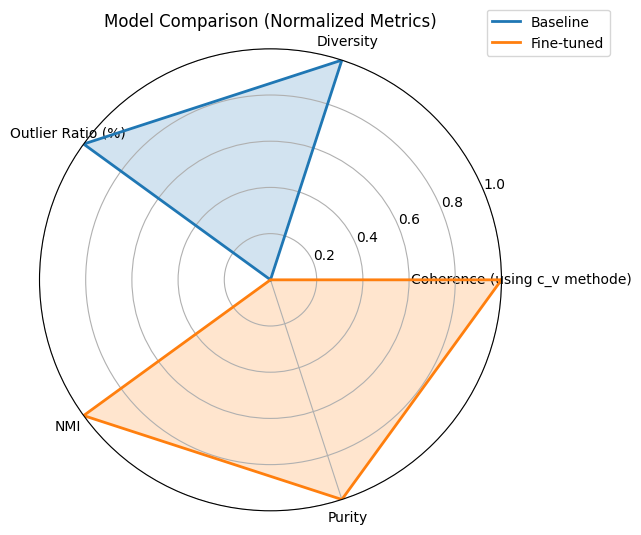

In [30]:
comparison_figs = topic_visualizer.generate_all_figs(
    compration_mode=True,
    metric_df=metric_comparison_df,
    topic_count_df=topic_count_df,
    outlier_df=outlier_comparison_df,
    radar_df=radar_df
)